# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# Embedding & ML
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Deployment
import joblib

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Import Dataset & Evaluate Data Structure

In [ ]:
dataset = pd.read_csv('https://raw.githubusercontent.com/DamaDamanik/nolimit-ds-test-dama-damanik/refs/heads/main/Data/GojekAppReviews.csv')
dataset

,userName,content,score,at,appVersion
0,Yuga Edit,akun gopay saya di blok,1,2022-01-21 10:52:12,4.9.3
1,ff burik,Lambat sekali sekarang ini bosssku apk gojek g...,3,2021-11-30 15:40:38,4.9.3
2,Anisa Suci Rahmayuliani,Kenapa sih dari kemarin sy buka aplikasi gojek...,4,2021-11-29 22:58:12,4.9.3
3,naoki yakuza,Baru download gojek dan hape baru trus ditop u...,1,2022-09-03 15:21:17,4.9.3
4,Trio Sugianto,Mantap,5,2022-01-15 10:05:27,4.9.3
...,...,...,...,...,...
224997,Sad Gamer,Gofood Biaya lain2ya gak ngotak mending hujan2...,1,2023-02-15 09:37:58,4.0.0
224998,fadhil fadil,Yok lah,5,2021-12-11 12:28:20,4.0.0
224999,g sugiarto,Sempurna,5,2022-03-14 01:45:39,4.0.0
225000,J i H A D 'B E,GOJEK LAMA LAMA GAK JELAS LAGI PESEN MASA MAP...,1,2021-12-24 08:48:51,4.0.0


In [ ]:
dataset.info()
dataset.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225002 entries, 0 to 225001
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   userName    225002 non-null  object
 1   content     225000 non-null  object
 2   score       225002 non-null  int64 
 3   at          225002 non-null  object
 4   appVersion  225002 non-null  object
dtypes: int64(1), object(4)
memory usage: 8.6+ MB


(225002, 5)

In [ ]:
dataset.describe()

,score
count,225002.000000
mean,3.928996
std,1.630551
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
dataset.isnull().sum()

,0
userName,0
content,2
score,0
at,0
appVersion,0


In [ ]:
dataset.duplicated().sum()

np.int64(0)

# Preprocessing

In [ ]:
dataset = dataset.rename(columns={"content":"review", "score":"rating"})
df = dataset[["review", "rating"]]
df

,review,rating
0,akun gopay saya di blok,1
1,Lambat sekali sekarang ini bosssku apk gojek g...,3
2,Kenapa sih dari kemarin sy buka aplikasi gojek...,4
3,Baru download gojek dan hape baru trus ditop u...,1
4,Mantap,5
...,...,...
224997,Gofood Biaya lain2ya gak ngotak mending hujan2...,1
224998,Yok lah,5
224999,Sempurna,5
225000,GOJEK LAMA LAMA GAK JELAS LAGI PESEN MASA MAP...,1


In [ ]:
df = df.dropna()
df.shape

(225000, 2)

In [ ]:
def mapping(n):
    if n > 3:
        return "positif"
    elif n == 3:
        return "netral"
    else:
        return "negatif"

df["sentiment"] = df["rating"].apply(mapping)
df

,review,rating,sentiment
0,akun gopay saya di blok,1,negatif
1,Lambat sekali sekarang ini bosssku apk gojek g...,3,netral
2,Kenapa sih dari kemarin sy buka aplikasi gojek...,4,positif
3,Baru download gojek dan hape baru trus ditop u...,1,negatif
4,Mantap,5,positif
...,...,...,...
224997,Gofood Biaya lain2ya gak ngotak mending hujan2...,1,negatif
224998,Yok lah,5,positif
224999,Sempurna,5,positif
225000,GOJEK LAMA LAMA GAK JELAS LAGI PESEN MASA MAP...,1,negatif


In [ ]:
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
positif,0.717196
negatif,0.240760
netral,0.042044


# EDA

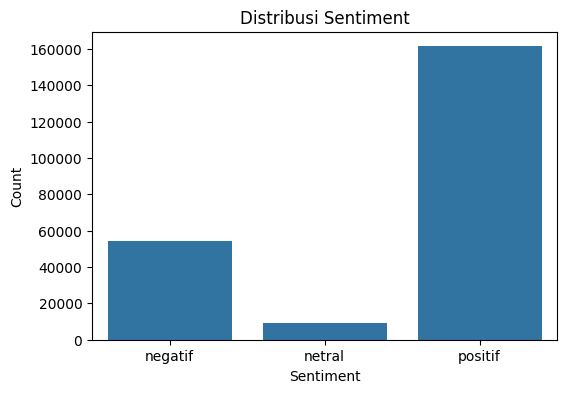

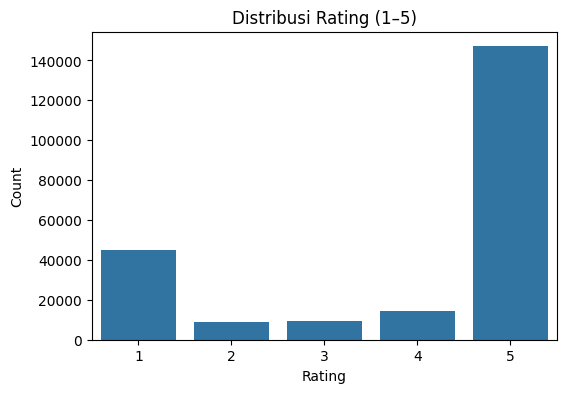

In [ ]:
columns = ['sentiment', 'rating']
titles = ['Distribusi Sentiment', 'Distribusi Rating (1–5)']
labels = ['Sentiment', 'Rating']
orders = [['negatif', 'netral', 'positif'], None]  # Order untuk sentiment, None untuk rating

# Looping untuk menghasilkan plot
for col, title, label, order in zip(columns, titles, labels, orders):
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], order=order)
    plt.title(title)
    plt.xlabel(label)
    plt.ylabel("Count")
    plt.show()

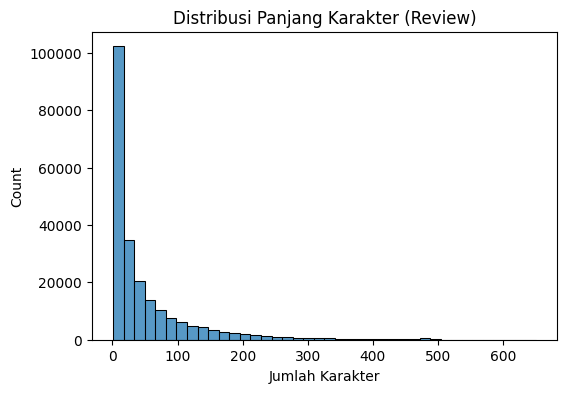

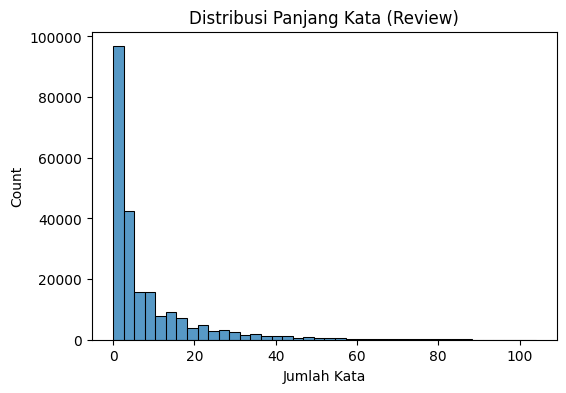

In [ ]:
columns = ['char_len', 'word_len']
titles = ['Distribusi Panjang Karakter (Review)', 'Distribusi Panjang Kata (Review)']
labels = ['Jumlah Karakter', 'Jumlah Kata']

# Menambahkan kolom baru untuk panjang karakter dan kata
df["char_len"] = df["review"].apply(len)  # Jumlah karakter
df["word_len"] = df["review"].apply(lambda x: len(x.split()))  # Jumlah kata

# Looping untuk menghasilkan plot
for col, title, label in zip(columns, titles, labels):
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=40)
    plt.title(title)
    plt.xlabel(label)
    plt.show()

In [ ]:
print("Statistik panjang karakter:")
print(df["char_len"].describe())

print("\nStatistik panjang kata:")
print(df["word_len"].describe())

Statistik panjang karakter:
count    225000.000000
mean         51.411667
std          74.673977
min           1.000000
25%           7.000000
50%          22.000000
75%          62.000000
max         650.000000
Name: char_len, dtype: float64

Statistik panjang kata:
count    225000.000000
mean          8.454427
std          12.249680
min           0.000000
25%           1.000000
50%           3.000000
75%          10.000000
max         104.000000
Name: word_len, dtype: float64


In [ ]:
def clean_review(text):
    text = str(text)

    text = re.sub(r"http\S+|www.\S+", "", text) # hapus URL
    text = re.sub(r'[\'"!#$%&()*+,-./:;<=>?@[\\]^_`{|}~]', ' ', text) # hapus tanda baca ASCII tetapi tidak menghapus emoji
    text = re.sub(r"\d+", "", text) # hapus angka
    text = re.sub(r"\s+", " ", text).strip() # normalisasi whitespace

    return text.lower()

In [ ]:
df["clean_review"] = df["review"].apply(clean_review)
df

,review,rating,sentiment,char_len,word_len,clean_review
0,akun gopay saya di blok,1,negatif,23,5,akun gopay saya di blok
1,Lambat sekali sekarang ini bosssku apk gojek g...,3,netral,57,10,lambat sekali sekarang ini bosssku apk gojek g...
2,Kenapa sih dari kemarin sy buka aplikasi gojek...,4,positif,136,24,kenapa sih dari kemarin sy buka aplikasi gojek...
3,Baru download gojek dan hape baru trus ditop u...,1,negatif,269,39,baru download gojek dan hape baru trus ditop u...
4,Mantap,5,positif,6,1,mantap
...,...,...,...,...,...,...
224997,Gofood Biaya lain2ya gak ngotak mending hujan2...,1,negatif,71,11,gofood biaya lainya gak ngotak mending hujanan...
224998,Yok lah,5,positif,7,2,yok lah
224999,Sempurna,5,positif,8,1,sempurna
225000,GOJEK LAMA LAMA GAK JELAS LAGI PESEN MASA MAP...,1,negatif,354,59,gojek lama lama gak jelas lagi pesen masa maps...


In [ ]:
df = df[df["clean_review"].str.split().str.len() >= 2]

print("Statistik panjang karakter:")
print(df["char_len"].describe())

print("\nStatistik panjang kata:")
print(df["word_len"].describe())

Statistik panjang karakter:
count    160967.000000
mean         69.871446
std          81.208556
min           3.000000
25%          18.000000
50%          38.000000
75%          88.000000
max         650.000000
Name: char_len, dtype: float64

Statistik panjang kata:
count    160967.000000
mean         11.419639
std          13.373501
min           2.000000
25%           3.000000
50%           6.000000
75%          14.000000
max         104.000000
Name: word_len, dtype: float64


# Embedding (Sentence-Transformers)

In [ ]:
df_copy = df[["clean_review", "rating", "sentiment"]]
df_copy

,clean_review,rating,sentiment
0,akun gopay saya di blok,1,negatif
1,lambat sekali sekarang ini bosssku apk gojek g...,3,netral
2,kenapa sih dari kemarin sy buka aplikasi gojek...,4,positif
3,baru download gojek dan hape baru trus ditop u...,1,negatif
6,coba dulu,2,negatif
...,...,...,...
224991,kenapa harus perbaruan mulu hedeh payah,1,negatif
224992,cepat pengirimannya,5,positif
224997,gofood biaya lainya gak ngotak mending hujanan...,1,negatif
224998,yok lah,5,positif


In [ ]:
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Mendapatkan dimensi embedding
sample_embedding = embedder.encode(["test"], show_progress_bar=False)
EMBEDDING_DIM = sample_embedding.shape[1]
print(f"Embedding dimension: {EMBEDDING_DIM}")

# Encode kolom clean_review
X = embedder.encode(df['clean_review'].tolist(), batch_size=128, show_progress_bar=True)
print(f"X shape: {X.shape}")

# Menyiapkan label
y = df['sentiment'].tolist()
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Classes: {label_encoder.classes_}")  # 0: negatif, 1: netral, 2: positif

Embedding dimension: 384


Batches:   0%|          | 0/1258 [00:00<?, ?it/s]

X shape: (160967, 384)
Classes: ['negatif' 'netral' 'positif']


# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,
                                                    test_size=0.2, random_state=42,
                                                    stratify=y_encoded)

In [ ]:
# Distribusi data train
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nTraining distribution:")
for cls, count in zip(label_encoder.classes_, counts):
    print(f"  {cls}: {count:,}")


Training distribution:
  negatif: 41,958
  netral: 6,899
  positif: 79,916


# Handle Imbalance Class

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Class weights (for handling imbalance):")
for i, (cls, weight) in enumerate(zip(label_encoder.classes_, class_weights)):
    print(f"  {cls} (class {i}): {weight:.4f}")

Class weights (for handling imbalance):
  negatif (class 0): 1.0230
  netral (class 1): 6.2218
  positif (class 2): 0.5371


# Modeling

In [ ]:
def build_model(input_dim, num_classes=3):
    model = Sequential([
        # Layer 1
        Dense(256, activation='relu', input_dim=input_dim,
              kernel_regularizer=tensorflow.keras.regularizers.l2(0.001),
              kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.4),

        # Layer 2
        Dense(128, activation='relu',
              kernel_regularizer=tensorflow.keras.regularizers.l2(0.001),
              kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 3
        Dense(64, activation='relu',
              kernel_regularizer=tensorflow.keras.regularizers.l2(0.001),
              kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.2),

        # FIX: Output layer untuk 3 kelas dengan softmax
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model(input_dim=EMBEDDING_DIM, num_classes=3)

print("\nModel Architecture:")
print("-" * 70)
model.summary()


Model Architecture:
----------------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,699 (553.51 KB)

 Trainable params: 140,803 (550.01 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Callbacks
checkpoint_cb = ModelCheckpoint(
    "gojek_sentiment_best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint_cb, early_stopping_cb, reduce_lr_cb]

# Train dengan class weights
print("\nTraining started...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Training started...
Epoch 1/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6140 - loss: 1.9115
Epoch 1: val_accuracy improved from -inf to 0.63863, saving model to gojek_sentiment_best_model.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.6142 - loss: 1.9108 - val_accuracy: 0.6386 - val_loss: 1.4966 - learning_rate: 0.0010
Epoch 2/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7091 - loss: 1.5406
Epoch 2: val_accuracy improved from 0.63863 to 0.75193, saving model to gojek_sentiment_best_model.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7092 - loss: 1.5404 - val_accuracy: 0.7519 - val_loss: 1.2587 - learning_rate: 0.0010
Epoch 3/50
189/202 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7254 - loss: 1.3455
Epoch 3: val_accuracy did not improve from 0.75193
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7255 - loss: 1.3427 - val_accuracy: 0.7293 - val_loss: 1.1099 - learning_rate: 0.0010
Epoch 4/50
192/202 ━━━━━━━━━━━━━━━━━━

# Evaluasi

In [ ]:
# Predictions
y_pred_prob = model.predict(X_test, batch_size=512)
y_pred = np.argmax(y_pred_prob, axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*70}")
print(f"  TEST ACCURACY: {accuracy:.4f} ({accuracy:.2%})")
print(f"{'='*70}")

# Classification report
print("\nClassification Report:")
print("-" * 70)
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("-" * 70)
print(f"{'':12} {'Pred Neg':>10} {'Pred Net':>10} {'Pred Pos':>10}")
print(f"{'Act Neg':>12} {cm[0,0]:>10} {cm[0,1]:>10} {cm[0,2]:>10}")
print(f"{'Act Net':>12} {cm[1,0]:>10} {cm[1,1]:>10} {cm[1,2]:>10}")
print(f"{'Act Pos':>12} {cm[2,0]:>10} {cm[2,1]:>10} {cm[2,2]:>10}")

# Per-class accuracy
print("\nPer-Class Accuracy:")
print("-" * 70)
for i, cls in enumerate(label_encoder.classes_):
    class_acc = cm[i, i] / cm[i, :].sum()
    print(f"  {cls:8s}: {class_acc:.2%}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

  TEST ACCURACY: 0.7548 (75.48%)

Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

     negatif     0.7904    0.6375    0.7058     10490
      netral     0.1391    0.4887    0.2165      1725
     positif     0.9488    0.8393    0.8907     19979

    accuracy                         0.7548     32194
   macro avg     0.6261    0.6552    0.6043     32194
weighted avg     0.8538    0.7548    0.7943     32194


Confusion Matrix:
----------------------------------------------------------------------
               Pred Neg   Pred Net   Pred Pos
     Act Neg       6687       3164        639
     Act Net        617        843        265
     Act Pos       1156       2054      16769

Per-Class Accuracy:
----------------------------------------------------------------------
  negatif : 63.75%
  netral  : 48.87%
  positif : 83.93%


## Visualisasi

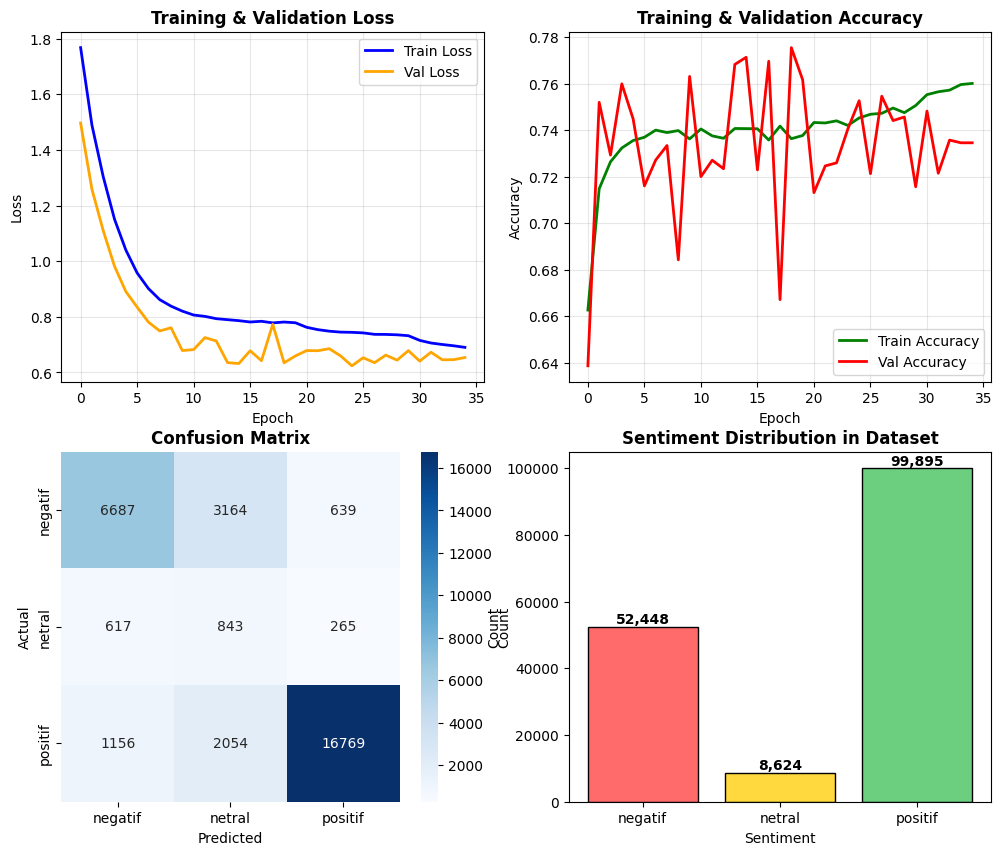

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Training History - Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[0, 0].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training History - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', color='red', linewidth=2)
axes[0, 1].set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# Distribusi Sentimen
sentiment_order = ['negatif', 'netral', 'positif']
sentiment_counts_plot = df['sentiment'].value_counts().reindex(sentiment_order)
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']
bars = axes[1, 1].bar(sentiment_order, sentiment_counts_plot.values, color=colors, edgecolor='black')
axes[1, 1].set_title('Sentiment Distribution in Dataset', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Count')
for bar, v in zip(bars, sentiment_counts_plot.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                    f'{v:,}', ha='center', fontweight='bold', fontsize=10)

plt.show()

# Prediksi Sampel untuk Memeriksa Hasil Model

In [ ]:
# Mengambil 10 sampel acak dari data uji untuk diperiksa hasil prediksinya
sample_indices = np.random.choice(len(X_test), 10, replace=False)

print("\nSample Predictions:")
print("-" * 70)

test_indices = []
for x_test_sample in X_test[sample_indices]:
    matches = np.where((X == x_test_sample).all(axis=1))[0]
    if len(matches) > 0:
        test_indices.append(matches[0])

for idx, test_idx in zip(sample_indices, test_indices):
    original_text = df.iloc[test_idx]['review'][:100]
    true_label = label_encoder.classes_[y_test[idx]]
    pred_label = label_encoder.classes_[y_pred[idx]]
    confidence = np.max(y_pred_prob[idx])

    status = "CORRECT" if true_label == pred_label else "WRONG"
    print(f"\n{status}")
    print(f"  Text: {original_text}")
    print(f"  True: {true_label:8s} | Pred: {pred_label:8s} | Confidence: {confidence:.2%}")


Sample Predictions:
----------------------------------------------------------------------

CORRECT
  Text: Sangat membantu transportasi di tp tinggal saya
  True: positif  | Pred: positif  | Confidence: 94.38%

CORRECT
  Text: Sangat membantu 
  True: positif  | Pred: positif  | Confidence: 92.42%

CORRECT
  Text: Banyak voucher menarik
  True: positif  | Pred: positif  | Confidence: 90.21%

WRONG
  Text: Saya gabisa memabatalkan pesanan soale uang tunai ku gada
  True: negatif  | Pred: netral   | Confidence: 51.23%

CORRECT
  Text: Banyak banget promomantappp sukak
  True: positif  | Pred: positif  | Confidence: 94.72%

CORRECT
  Text: Untuk saat ini Alhamdulillah memuaskan
  True: positif  | Pred: positif  | Confidence: 91.74%

CORRECT
  Text: Cukup membantu disaat butuh mau bepergian
  True: positif  | Pred: positif  | Confidence: 88.31%

CORRECT
  Text: Ko makin kesini hofood nya ga bisa di gabung promonya Padahal dulu bisa tolong di balikin Kay dulu a
  True: netral   | Pred: ne

# Deployment

In [ ]:
# Save Model
model.save('gojek_sentiment_final_model.keras')

# Save label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']